### Uploading images

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt


In [2]:
image_gray = cv2.imread("images/plane.jpg", cv2.IMREAD_GRAYSCALE)


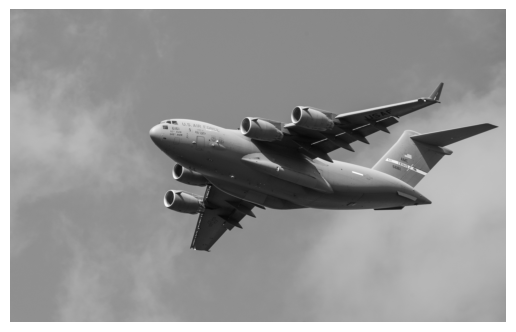

In [3]:
plt.imshow(image_gray, cmap="gray")
plt.axis("off")
plt.show()


In [4]:
type(image_gray)

numpy.ndarray

In [5]:
image_gray

array([[140, 136, 146, ..., 132, 139, 134],
       [144, 136, 149, ..., 142, 124, 126],
       [152, 139, 144, ..., 121, 127, 134],
       ...,
       [156, 146, 144, ..., 157, 154, 151],
       [146, 150, 147, ..., 156, 158, 157],
       [143, 138, 147, ..., 156, 157, 157]],
      shape=(2270, 3600), dtype=uint8)

### Load color image

In [6]:
image_bgr = cv2.imread("images/plane.jpg", cv2.IMREAD_COLOR)
image_bgr[0, 0]

array([195, 144, 111], dtype=uint8)

### Convert BGR to RGB

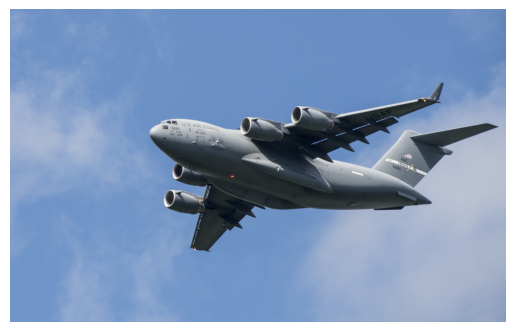

In [7]:
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

### Saving images

In [8]:
cv2.imwrite("images/plane_new.jpg", image_gray)

True

### Resizing images

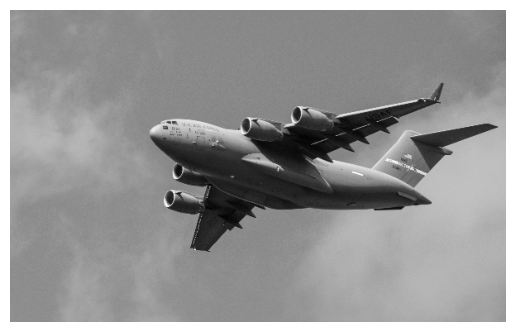

In [9]:
image_600x378 = cv2.resize(image_gray, (600, 378))
plt.imshow(image_600x378, cmap="gray")
plt.axis("off")
plt.show()

### Cropped image

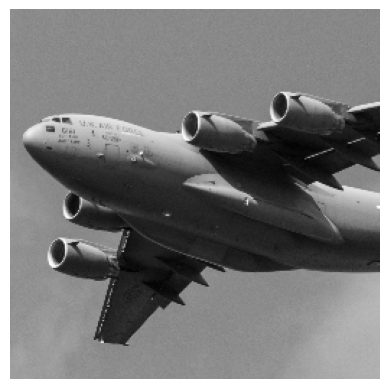

In [10]:
image_cropped = image_600x378[60:316, 160:416]
#Save the cropped image 256x256 pixels
cv2.imwrite("images/plane_gray_256.jpg", image_cropped)
plt.imshow(image_cropped, cmap="gray")
plt.axis("off")
plt.show()

### Blurring images

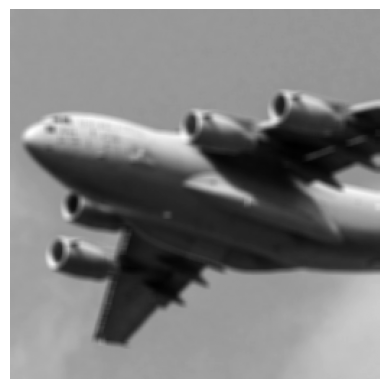

In [11]:
image_blurry = cv2.blur(image_cropped, (5, 5))
plt.imshow(image_blurry, cmap="gray")
plt.axis("off")
plt.show()


### Create kernel

In [12]:
kernel = np.ones((5, 5)) / 25.0
kernel


array([[0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04]])

### Use kernel and filter2D function for same blur effect

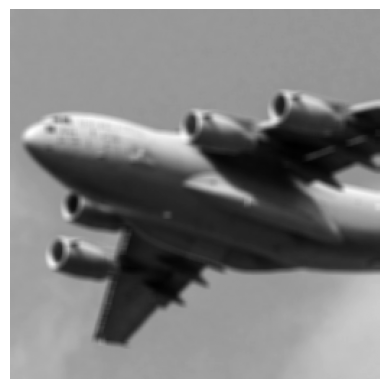

In [13]:
image_kernel = cv2.filter2D(image_cropped, -1, kernel)

plt.imshow(image_kernel, cmap="gray")
plt.axis("off")
plt.show()

### Adjusting image sharpness

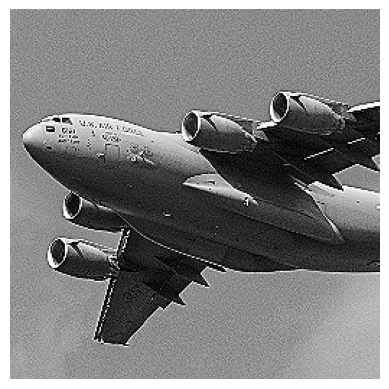

In [14]:
kernel_sharp = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]])
image_sharp = cv2.filter2D(image_cropped, -1, kernel_sharp)
plt.imshow(image_sharp, cmap="gray")
plt.axis("off")
plt.show()

### Increasing contrast

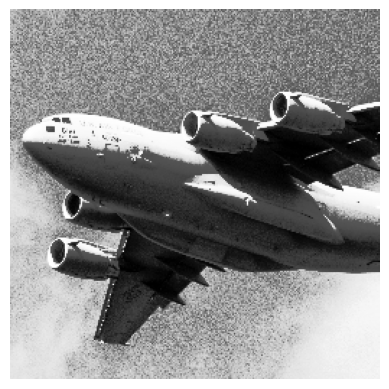

In [15]:
image_enhanced = cv2.equalizeHist(image_cropped)
plt.imshow(image_enhanced, cmap="gray")
plt.axis("off")
plt.show()

### Increasing contrast for color image

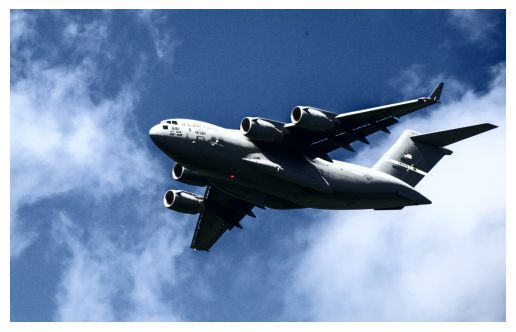

In [16]:
# convert to YUV
image_yuv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YUV)

# Perform histogram equalization on the Y channel
image_yuv[:, :, 0] = cv2.equalizeHist(image_yuv[:, :, 0])

# Convert to RGB
image_rgb = cv2.cvtColor(image_yuv, cv2.COLOR_YUV2RGB)

plt.imshow(image_rgb, cmap="gray")
plt.axis("off")
plt.show()

### Color recognition

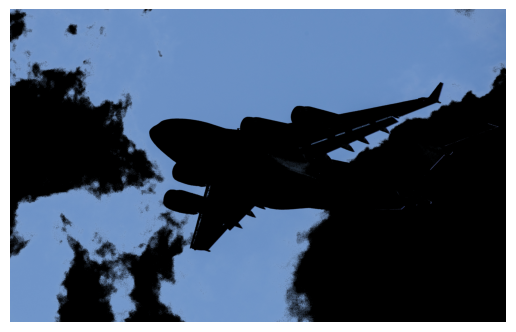

In [17]:
image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

# Let's define the range of blue values ​​in HSV
lower_blue = np.array([50, 100, 50])
upper_blue = np.array([130, 255, 255])

mask = cv2.inRange(image_hsv, lower_blue, upper_blue)

image_bgr_masked = cv2.bitwise_and(image_bgr, image_bgr, mask=mask)

image_rgb = cv2.cvtColor(image_bgr_masked, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb, cmap="gray")
plt.axis("off")
plt.show()

### Image binarization

#### ADAPTIVE_THRESH_GAUSSIAN_C

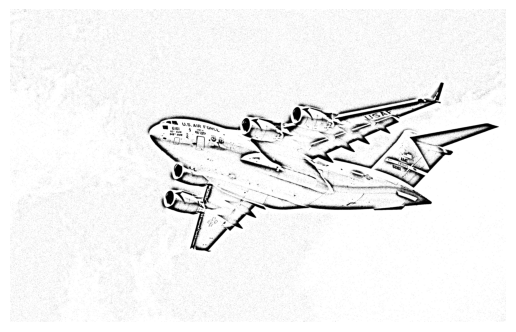

In [18]:
max_output_value = 255
neighborhood_size = 99
subtract_from_mean = 10

image_binarized = cv2.adaptiveThreshold(
    image_gray,
    max_output_value,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    neighborhood_size,
    subtract_from_mean,
)

plt.imshow(image_binarized, cmap="gray")
plt.axis("off")
plt.show()

#### ADAPTIVE_THRESH_MEAN_C

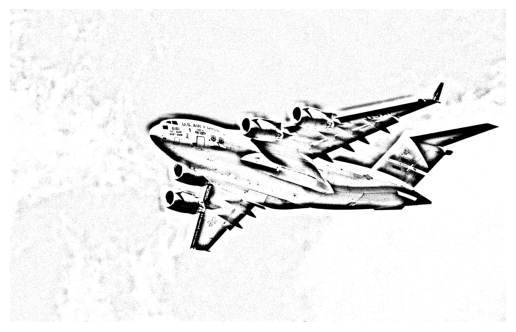

In [19]:
image_binarized_mean_thresh = cv2.adaptiveThreshold(
    image_gray,
    max_output_value,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    neighborhood_size,
    subtract_from_mean,
)

plt.imshow(image_binarized_mean_thresh, cmap="gray")
plt.axis("off")
plt.show()


### Background removal

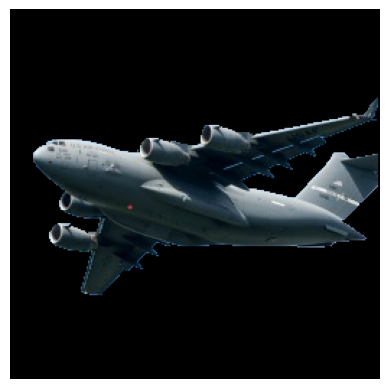

In [20]:
image_bgr_256 = cv2.imread("images/plane_256x256.jpg", cv2.IMREAD_COLOR)
image_rgb_256 = cv2.cvtColor(image_bgr_256, cv2.COLOR_BGR2RGB)

mask = np.zeros(image_rgb_256.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# підберіть під об'єкт
rect = (0, 56, 255, 150)
cv2.grabCut(image_rgb_256, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

mask_2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
image_rgb_nobg = image_rgb_256 * mask_2[:, :, np.newaxis]

plt.imshow(image_rgb_nobg)
plt.axis("off")
plt.show()


### Show mask

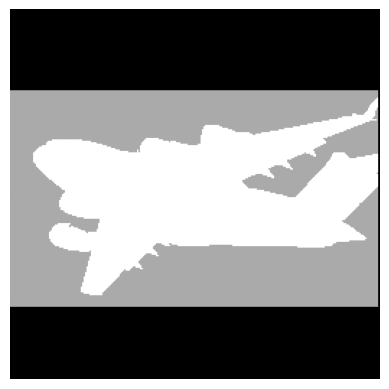

In [21]:
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()


### Show mask 2

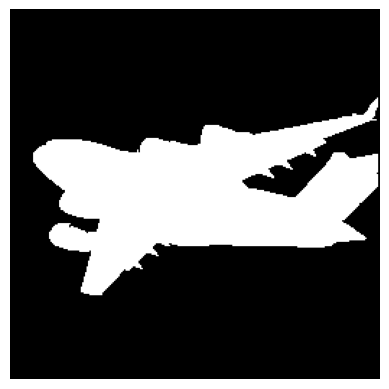

In [22]:
plt.imshow(mask_2, cmap="gray")
plt.axis("off")
plt.show()


### Defining boundaries

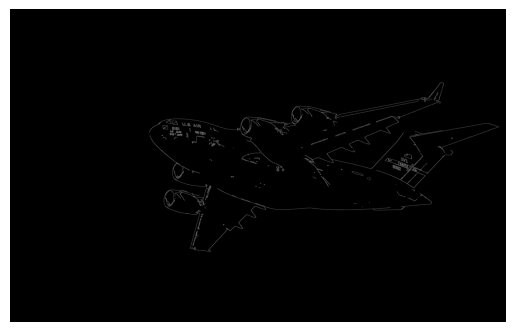

In [23]:
median_intensity = np.median(image_gray)

lower_threshold = int(max(0, (1.0 - 0.33) * median_intensity))
upper_threshold = int(min(255, (1.0 + 0.33) * median_intensity))

image_canny = cv2.Canny(image_gray, lower_threshold, upper_threshold)

plt.imshow(image_canny, cmap="gray")
plt.axis("off")
plt.show()

### Angle detection

#### Harris detector

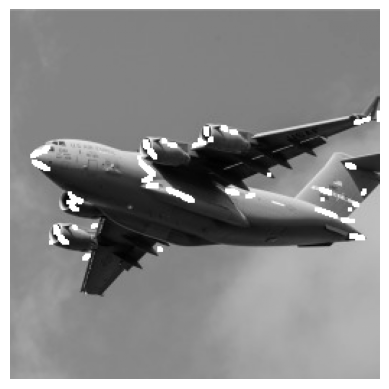

In [24]:
image_gray_256 = cv2.cvtColor(image_bgr_256, cv2.COLOR_BGR2GRAY)
image_gray_256 = np.float32(image_gray_256)

# Set parameters for corner detection
block_size = 2
aperture = 29
free_parameter = 0.04

# Detect corners
detector_responses = cv2.cornerHarris(image_gray_256, block_size, aperture, free_parameter)

# Increase corner indicators
detector_responses = cv2.dilate(detector_responses, None)

# Rest value of the image to black,highlight corners in white
threshold = 0.02
image_bgr_256[detector_responses > threshold * detector_responses.max()] = [255,255,255]

image_gray_256 = cv2.cvtColor(image_bgr_256, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray_256, cmap="gray")
plt.axis("off")
plt.show()

### Output detector

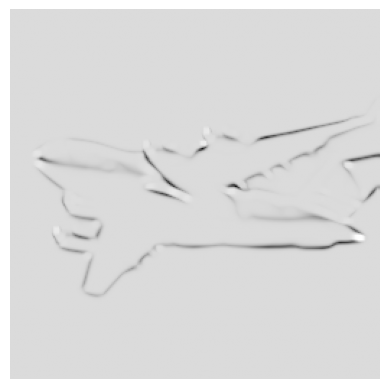

In [25]:
plt.imshow(detector_responses, cmap="gray")
plt.axis("off")
plt.show()

#### Detector Shi-Tomasi

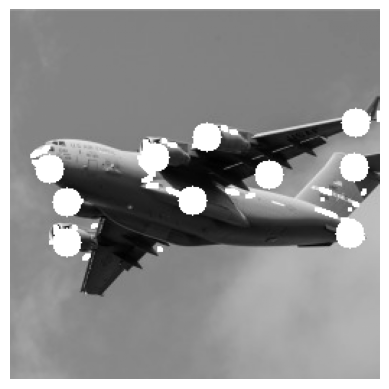

In [26]:
# Set parameters for Shi-Tomasi corner detection
corners_to_detect = 10
minimum_quality_score = 0.05
minimum_distance = 25

# Detect corners using Shi-Tomasi method
corners = cv2.goodFeaturesToTrack(
    image_gray_256, 
    corners_to_detect, 
    minimum_quality_score, 
    minimum_distance
)

corners = np.int16(corners)

# Обвести каждый угол белым кругом
for corner in corners:
    x, y = corner[0]
    cv2.circle(image_bgr_256, (x, y), 10, (255, 255, 255), -1)

# Преобразовать в оттенки серого
image_gray_256 = cv2.cvtColor(image_bgr_256, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray_256, cmap="gray")
plt.axis("off")
plt.show()

### Creating features for machine learning

In [27]:
image_10x10 = cv2.resize(image_gray_256, (10, 10))

image_10x10.flatten()


array([133, 130, 130, 129, 130, 129, 129, 128, 128, 127, 135, 131, 131,
       131, 130, 130, 129, 128, 128, 128, 134, 132, 131, 131, 130, 129,
       129, 128, 130, 133, 132, 158, 130, 133, 130, 255,  97,  26, 132,
       143, 141,  36,  54,  91,   9,   9,  49, 144, 179, 255, 142, 255,
        32,  36,  29,  43, 113, 141, 255, 187, 141, 255,  26,  25, 132,
       135, 151, 175, 174, 184, 143, 151,  38, 133, 134, 139, 174, 177,
       169, 174, 155, 141, 135, 137, 137, 152, 169, 168, 168, 179, 152,
       139, 136, 135, 137, 143, 159, 166, 171, 175], dtype=uint8)

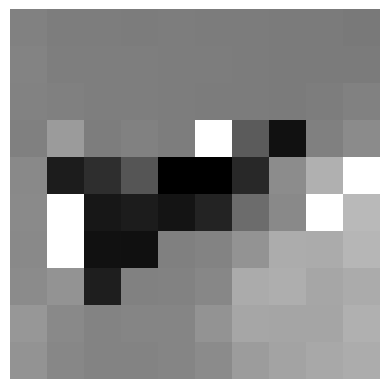

In [28]:
plt.imshow(image_10x10, cmap="gray")
plt.axis("off")
plt.show()


### Features in color

In [29]:
image_color_10x10 = cv2.resize(image_rgb_256, (10, 10))

image_color_10x10.flatten().shape


(300,)

In [30]:
image_gray_256.flatten().shape


(65536,)

In [31]:
image_rgb_256.flatten().shape

(196608,)

### Creating histograms of colors as features

In [32]:
np.random.seed(0)
features = []
colors = ("r", "g", "b")

for i, channel in enumerate(colors):
    histogram = cv2.calcHist(
        [image_rgb_256],
        [i],        # Channel index
        None,       # Without mask
        [256],      # Histogram size
        [0, 256],   # Range of pixel values
    ) 
    features.extend(histogram)
    
# Create vector of features
observation = np.array(features).flatten()

observation[0:5]

array([1027.,  217.,  182.,  146.,  146.], dtype=float32)

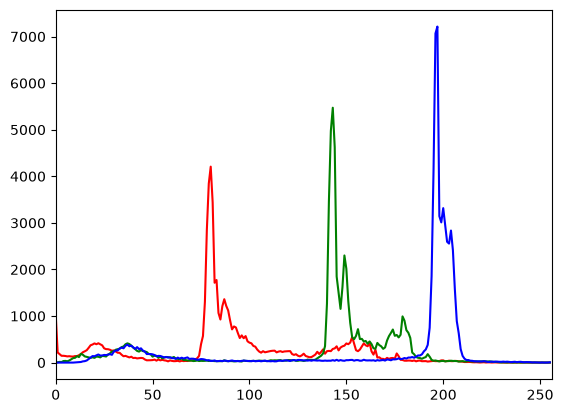

In [33]:
for i, channel in enumerate(colors):
    histogram = cv2.calcHist(
        [image_rgb_256],
        [i],  # Channel index
        None,  # Without mask
        [256],  # Histogram size
        [0, 256],  # Range of pixel values
    )
    plt.plot(histogram, color=channel)
    plt.xlim([0, 256])
    
plt.show()


### Using pre-trained embeddings as features

In [34]:
import torch
from torchvision import transforms
import torchvision.models as models

# Convert the image to a PyTorch tensor
convert_tensor = transforms.ToTensor()
pytorch_image = convert_tensor(np.array(image_bgr))

# Load a pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)

# Get the average pooling layer from the model
layer = model._modules.get('avgpool')

# Define a function to extract features from the image
model.eval()

with torch.no_grad():
    embedding = model(pytorch_image.unsqueeze(0))

print(embedding.shape)

/home/max/projects/machine-learning/08_handling_images/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/max/projects/machine-learning/08_handling_images/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([1, 1000])


In [35]:
import tensorflow as tf
import tensorflow_hub as hub

# Convert the image to a TensorFlow tensor
tf_image = tf.image.convert_image_dtype([image_rgb], tf.float32)

# Create a TensorFlow Hub KerasLayer for the Inception V1 model
embedding_model = hub.KerasLayer(
    "https://tfhub.dev/google/imagenet/inception_v1/feature_vector/5"
)
embeddings = embedding_model(tf_image)

print(embeddings.shape)

I0000 00:00:1786616543.128618   31759 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786616543.395999   31759 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786616544.747901   31759 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786616544.749636   31759 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will 

(1, 1024)


### Object Recognition with OpenCV

#### Haar cascade classifiers

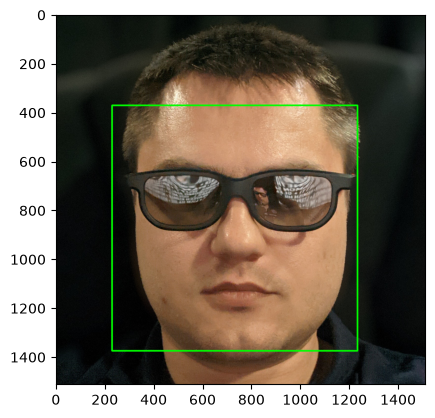

In [36]:
import cv2
from matplotlib import pyplot as plt

cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    raise FileNotFoundError(f'Could not load Haar cascade from {cascade_path}')

image_face_bgr = cv2.imread("images/face.jpg", cv2.IMREAD_COLOR)
image_face_rgb = cv2.cvtColor(image_face_bgr, cv2.COLOR_BGR2RGB)

# Detect faces in the image
faces = face_cascade.detectMultiScale(image_face_rgb)

for (x, y, w, h) in faces:
    cv2.rectangle(image_face_rgb, (x, y),
                (x + h, y + w),
                (0, 255, 0), 5)

plt.subplot(1, 1, 1)
plt.imshow(image_face_rgb)
plt.show()

### Image Classification with Pytorch

In [37]:
import cv2
import numpy as np
import torch
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18

# Load the pre-trained ResNet-18 model with default weights
weights = ResNet18_Weights.DEFAULT
imagenet_class_index = {
    str(index): [category, category]
    for index, category in enumerate(weights.meta["categories"])
}

# Load a pre-trained ResNet-18 model with the specified weights
model = resnet18(weights=weights)

# Convert the image to a PyTorch tensor
convert_tensor = transforms.ToTensor()
pytorch_image = convert_tensor(np.array(image_rgb))

# Set the model to evaluation mode
model.eval()

# Make a prediction using the model
prediction = model(pytorch_image.unsqueeze(0))

# Get the index of the class with the highest probability
index = torch.argmax(prediction, 1)

# Get the class label corresponding to the predicted index
percentage = torch.nn.functional.softmax(prediction, dim=1)[0] * 100

# Print the predicted class label and its probability
print(
    imagenet_class_index[str(index.tolist()[0])][1],
    percentage[index.tolist()[0]].item(),
)

nematode 6.111506938934326
